# Kalibrasi dan Runtime Hybrid Sentiment–Topic
Alur utama notebook: **data masuk → preprocessing → rule-based SO-CAL → IndoBERT → hybrid fusion → sentimen final → pemodelan topik**. Bagian setelah alur utama berisi diagnostik artefak, evaluasi, dan visualisasi.


In [1]:
from pathlib import Path
from collections import Counter
import json
import subprocess
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import polars as pl
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.artifact_service import ArtifactService

artifact_service = ArtifactService()
PROJECT_ROOT


e:\Software\laragon\bin\python\python-3.13.11-amd64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('E:/School/tugas-akhir/project')

## 1. Konfigurasi Eksekusi


In [2]:
EXPERIMENT_ID = "indobert_nlp_manual"
EXPERIMENT_DIR = Path(config.EXPERIMENT_CONFIG["artifact_root"]) / EXPERIMENT_ID
MODEL_DIR = EXPERIMENT_DIR / "model"
CALIBRATION_ARTIFACT_PATH = EXPERIMENT_DIR / "calibration_artifact.json"
INDOBERT_METRICS_PATH = EXPERIMENT_DIR / "indobert_metrics.json"
FUSION_POLICY_PATH = EXPERIMENT_DIR / "fusion_policy.json"
FUSION_METRICS_PATH = EXPERIMENT_DIR / "metrics.json"
HYBRID_TEST_PREDICTIONS_PATH = EXPERIMENT_DIR / "test_predictions.parquet"
HYBRID_RUNTIME_DIR = EXPERIMENT_DIR / "runtime_hybrid"
HYBRID_PREDICTIONS_PATH = HYBRID_RUNTIME_DIR / "scenario_without_llm_predictions.parquet"
HYBRID_PREDICTIONS_CSV_PATH = HYBRID_RUNTIME_DIR / "scenario_without_llm_predictions.csv"
HYBRID_RUNTIME_SUMMARY_PATH = HYBRID_RUNTIME_DIR / "scenario_without_llm_summary.json"
HYBRID_RUNTIME_MANIFEST_PATH = HYBRID_RUNTIME_DIR / "scenario_without_llm_manifest.json"
HYBRID_REPORT_DIR = HYBRID_RUNTIME_DIR / "report"
HYBRID_CLASSIFICATION_REPORT_PATH = HYBRID_REPORT_DIR / "hybrid_classification_report.parquet"
HYBRID_EVALUATION_METRICS_PATH = HYBRID_REPORT_DIR / "hybrid_evaluation_metrics.json"
HYBRID_FIGURES_DIR = HYBRID_REPORT_DIR / "figures"
HYBRID_REPORT_MANIFEST_PATH = HYBRID_REPORT_DIR / "hybrid_report_manifest.json"
HYBRID_SENTIMENT_FIGURE_PATH = HYBRID_FIGURES_DIR / "hybrid_sentiment_distribution.png"
HYBRID_KALBAR_FIGURE_PATH = HYBRID_FIGURES_DIR / "kalbar_location_distribution.png"

RUN_BUILD_TRAINING_DATASET = True
RUN_BUILD_RAW_CANDIDATE_SCHEMA = False
RUN_CREATE_FIXED_SPLIT = True
RUN_TRAIN_MODEL = not (MODEL_DIR / "config.json").exists()
RUN_CALIBRATE_INDOBERT = True
RUN_RUNTIME_HYBRID = True
RUN_TOPIC_EXTRACTION = False  # run-hybrid-nlp sudah menghasilkan artefak topik
RUN_REPORT_VISUALIZATIONS = True
TOPIC_TOP_N = 5
RUNTIME_LIMIT = None

print("Experiment dir:", EXPERIMENT_DIR)
print("Fusion policy:", FUSION_POLICY_PATH)
print("Fusion metrics:", FUSION_METRICS_PATH)
print("Model exists:", (MODEL_DIR / "config.json").exists())
print("RUN_TRAIN_MODEL:", RUN_TRAIN_MODEL)
print("RUNTIME_LIMIT:", RUNTIME_LIMIT)


Experiment dir: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual
Fusion policy: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\fusion_policy.json
Fusion metrics: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\metrics.json
Model exists: True
RUN_TRAIN_MODEL: False
RUNTIME_LIMIT: None


## 2. Jalankan Tahap Dataset dan Model


In [3]:
stages = [
    (
        "build-training-dataset",
        RUN_BUILD_TRAINING_DATASET,
        [sys.executable, "main.py", "build-training-dataset"],
    ),
    (
        "build-raw-candidate-schema",
        RUN_BUILD_RAW_CANDIDATE_SCHEMA,
        [sys.executable, "main.py", "build-raw-candidate-schema"],
    ),
    (
        "create-fixed-group-split",
        RUN_CREATE_FIXED_SPLIT,
        [sys.executable, "main.py", "create-fixed-group-split"],
    ),
    (
        "train-indobert",
        RUN_TRAIN_MODEL,
        [sys.executable, "main.py", "train-indobert", "--experiment-id", EXPERIMENT_ID],
    ),
    (
        "calibrate-indobert-for-hybrid",
        RUN_CALIBRATE_INDOBERT,
        [
            sys.executable,
            "main.py",
            "calibrate-indobert",
            "--dataset",
            str(config.TRAINING_DATASET_WITH_SPLIT_PATH),
            "--experiment-dir",
            str(EXPERIMENT_DIR),
        ],
    ),
]

completed_stages = []
for stage_name, enabled, command in tqdm(stages, desc="Persiapan Hybrid NLP", unit="stage"):
    if not enabled:
        tqdm.write(f"SKIP {stage_name}")
        completed_stages.append({"stage": stage_name, "status": "skipped"})
        continue

    tqdm.write(f"RUN  {stage_name}")
    tqdm.write(" ".join(str(part) for part in command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    completed_stages.append({"stage": stage_name, "status": "done"})

completed_stages


Persiapan Hybrid NLP:   0%|          | 0/5 [00:00<?, ?stage/s]

RUN  build-training-dataset
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py build-training-dataset


Persiapan Hybrid NLP:  20%|██        | 1/5 [00:00<00:03,  1.04stage/s]

SKIP build-raw-candidate-schema
RUN  create-fixed-group-split
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py create-fixed-group-split


Persiapan Hybrid NLP:  60%|██████    | 3/5 [00:06<00:04,  2.15s/stage]

SKIP train-indobert
RUN  calibrate-indobert-for-hybrid
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py calibrate-indobert --dataset E:\School\tugas-akhir\project\outputs\datasets\training_dataset_with_split.parquet --experiment-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual


Persiapan Hybrid NLP: 100%|██████████| 5/5 [01:31<00:00, 18.37s/stage]


[{'stage': 'build-training-dataset', 'status': 'done'},
 {'stage': 'build-raw-candidate-schema', 'status': 'skipped'},
 {'stage': 'create-fixed-group-split', 'status': 'done'},
 {'stage': 'train-indobert', 'status': 'skipped'},
 {'stage': 'calibrate-indobert-for-hybrid', 'status': 'done'}]

## 3. Data → Rule-Based → IndoBERT → Hybrid Sentiment


In [4]:
from main import summarize_fusion_facts

hybrid_summary = None
hybrid_result_df = None
hybrid_report_outputs = {}

if RUN_RUNTIME_HYBRID:
    required_artifacts = [MODEL_DIR / "config.json", CALIBRATION_ARTIFACT_PATH, FUSION_POLICY_PATH]
    missing_artifacts = [path for path in required_artifacts if not path.exists()]
    if missing_artifacts:
        raise FileNotFoundError(f"Artifact hybrid belum lengkap: {missing_artifacts}")

    command = [
        sys.executable, "main.py", "run-hybrid-nlp",
        "--input", str(config.RAW_CANDIDATE_SCHEMA_PATH),
        "--model-dir", str(MODEL_DIR),
        "--calibration-artifact", str(CALIBRATION_ARTIFACT_PATH),
        "--fusion-policy", str(FUSION_POLICY_PATH),
        "--output-dir", str(HYBRID_RUNTIME_DIR),
        "--report-dir", str(HYBRID_REPORT_DIR),
    ]
    if RUNTIME_LIMIT is not None:
        command.extend(["--limit", str(RUNTIME_LIMIT)])
    if not RUN_REPORT_VISUALIZATIONS:
        command.append("--skip-visualizations")
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    hybrid_summary = artifact_service.load_json(HYBRID_RUNTIME_SUMMARY_PATH)
elif HYBRID_RUNTIME_SUMMARY_PATH.exists():
    hybrid_summary = artifact_service.load_json(HYBRID_RUNTIME_SUMMARY_PATH)

if HYBRID_PREDICTIONS_PATH.exists():
    hybrid_result_df = pl.read_parquet(HYBRID_PREDICTIONS_PATH)
    report_manifest_path = HYBRID_REPORT_DIR / "hybrid_report_manifest.json"
    hybrid_report_outputs = (
        artifact_service.load_json(report_manifest_path).get("outputs", {})
        if report_manifest_path.exists() else {}
    )
    print(f"Hybrid predictions: {HYBRID_PREDICTIONS_PATH}")
    print(f"Hybrid policy: {FUSION_POLICY_PATH}")
    print(f"Hybrid summary: {HYBRID_RUNTIME_SUMMARY_PATH}")
    print(f"Hybrid report: {HYBRID_REPORT_DIR}")
else:
    print("Output hybrid belum tersedia.")


Hybrid predictions: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_hybrid\scenario_without_llm_predictions.parquet
Hybrid policy: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\fusion_policy.json
Hybrid summary: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_hybrid\scenario_without_llm_summary.json
Hybrid report: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_hybrid\report


## 4. Sentimen Final → Keyword SO-CAL per Kelas Sentimen


In [5]:
TOPIC_DIR = HYBRID_RUNTIME_DIR / "topics"
TOPIC_ASSIGNMENTS_PATH = TOPIC_DIR / "topic_assignments.parquet"
TOPIC_SUMMARY_PATH = TOPIC_DIR / "topic_summary.json"
TOPIC_KEYWORD_BLACKLIST_PATH = config.TOPIC_KEYWORD_BLACKLIST_PATH

topic_summary = None
topic_assignments_df = None
if TOPIC_SUMMARY_PATH.exists() and TOPIC_ASSIGNMENTS_PATH.exists():
    topic_summary = artifact_service.load_json(TOPIC_SUMMARY_PATH)
    topic_assignments_df = pl.read_parquet(TOPIC_ASSIGNMENTS_PATH)
    print(f"Keyword blacklist: {TOPIC_KEYWORD_BLACKLIST_PATH}")
else:
    print("Output topik belum tersedia.")


Keyword blacklist: E:\School\tugas-akhir\project\resources\topic_keyword_blacklist.json


In [6]:
def build_topic_keyword_frame(topic_summary):
    rows = []
    for sentiment in config.TOPIC_SENTIMENT_ORDER:
        sentiment_summary = topic_summary.get("sentiment_keywords", {}).get(sentiment, {})
        for detail in sentiment_summary.get("keyword_details", []):
            rows.append({"sentiment": sentiment, **detail})
    return pl.DataFrame(rows) if rows else pl.DataFrame()


if topic_summary is None:
    print("Output topik belum tersedia.")
else:
    keyword_detail_df = build_topic_keyword_frame(topic_summary)
    sentiment_overview_df = pl.DataFrame([
        {
            "sentiment": sentiment,
            "n_documents": int(topic_summary["sentiment_keywords"][sentiment]["n_documents"]),
            "keyword_count": int(topic_summary["sentiment_keywords"][sentiment]["keyword_count"]),
        }
        for sentiment in config.TOPIC_SENTIMENT_ORDER
    ])
    display(sentiment_overview_df)
    if keyword_detail_df.is_empty():
        print("Keyword topik tidak tersedia.")
    else:
        display(keyword_detail_df)
        fig, axes = plt.subplots(3, 1, figsize=(14, 15), squeeze=False)
        palette = {"positif": "#59A14F", "netral": "#BFBFBF", "negatif": "#E15759"}
        for row_index, sentiment in enumerate(config.TOPIC_SENTIMENT_ORDER):
            ax = axes[row_index][0]
            sentiment_df = keyword_detail_df.filter(pl.col("sentiment") == sentiment)
            if sentiment_df.is_empty():
                ax.set_axis_off()
                ax.set_title(f"Keyword topik {sentiment} tidak tersedia")
                continue
            plot_df = sentiment_df.sort("rank").head(TOPIC_TOP_N).sort("frequency")
            ax.barh(plot_df["keyword"].to_list(), plot_df["frequency"].to_list(), color=palette[sentiment])
            ax.set_title(f"Keyword SO-CAL {sentiment.title()}")
            ax.set_xlabel("Jumlah Kemunculan")
        fig.tight_layout(pad=1.2)
        plt.close(fig)  # figure kanonis ditampilkan dari artefak report


sentiment,n_documents,keyword_count
str,i64,i64
"""positif""",7442,10
"""netral""",5377,1
"""negatif""",3648,10


sentiment,keyword,source,sentiment_label,category,frequency,document_frequency,socal_weight,blacklist_overridden,rank
str,str,str,str,str,i64,i64,f64,bool,i64
"""positif""","""pertumbuhan ekonomi""","""socal_phrase""","""positif""","""economic_impact""",125,123,1.4,false,1
"""positif""","""terima kasih""","""socal_phrase""","""positif""","""user_satisfaction""",98,94,1.4,false,2
"""positif""","""kesejahteraan masyarakat""","""socal_phrase""","""positif""","""social_impact""",75,73,1.6,false,3
"""positif""","""membuka peluang""","""socal_phrase""","""positif""","""economic_impact""",57,57,1.4,false,4
"""positif""","""aktivitas ekonomi""","""socal_phrase""","""positif""","""economic_impact""",33,33,1.3,false,5
…,…,…,…,…,…,…,…,…,…
"""negatif""","""rakus lahan""","""socal_phrase""","""negatif""","""environmental_impact""",2,2,1.7,false,6
"""negatif""","""jauh dari optimal""","""socal_phrase""","""negatif""","""system_performance""",1,1,1.7,false,7
"""negatif""","""kerusakan hutan""","""socal_phrase""","""negatif""","""environmental_impact""",1,1,1.7,false,8


## 5. Visualisasi Hybrid NLP


In [7]:
import matplotlib.pyplot as plt

LABEL_ORDER = ["negatif", "netral", "positif"]


def counts_from_series(values):
    counts = {}
    for value in values:
        key = str(value)
        counts[key] = counts.get(key, 0) + 1
    return counts


def plot_count_bar(ax, counts, title, xlabel="Kategori", ylabel="Jumlah", order=None):
    labels = list(order or counts.keys())
    values = [counts.get(label, 0) for label in labels]
    ax.bar(labels, values, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    for index, value in enumerate(values):
        ax.text(index, value, str(value), ha="center", va="bottom", fontsize=9)


def plot_confusion_matrix(ax, matrix, title):
    values = [
        [int(matrix.get(actual, {}).get(predicted, 0)) for predicted in LABEL_ORDER]
        for actual in LABEL_ORDER
    ]
    image = ax.imshow(values, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=25, ha="right")
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    threshold = max([item for row in values for item in row] or [0]) / 2
    for row_index, row in enumerate(values):
        for col_index, value in enumerate(row):
            color = "white" if value > threshold else "black"
            ax.text(col_index, row_index, str(value), ha="center", va="center", color=color)
    return image


In [8]:
hybrid_visual_df = (
    globals().get("hybrid_result_df")
    if globals().get("hybrid_result_df") is not None
    else pl.read_parquet(HYBRID_PREDICTIONS_PATH) if HYBRID_PREDICTIONS_PATH.exists() else None
)

if hybrid_visual_df is None:
    print("Output hybrid belum tersedia.")
else:
    runtime_facts = summarize_fusion_facts(hybrid_visual_df)
    fact_labels = {
        "total_rows": "Total output runtime",
        "changed_from_indobert_count": "Label berubah dari IndoBERT",
        "cross_method_conflict_count": "Konflik antarmetode",
        "requires_llm_count": "Memerlukan LLM",
        "needs_review_count": "Memerlukan review",
    }
    runtime_fact_df = pl.DataFrame(
        [
            {"fakta": label, "jumlah": int(runtime_facts.get(key, 0))}
            for key, label in fact_labels.items()
        ]
    )
    display(runtime_fact_df)
    print(
        "Runtime tidak memiliki label aktual; angka di atas adalah fakta routing, "
        "bukan ukuran accuracy."
    )

    final_counts = counts_from_series(hybrid_visual_df["final_sentiment"].to_list())
    fusion_counts = dict(runtime_facts["fusion_action_distribution"])
    rule_counts = counts_from_series(hybrid_visual_df[config.COL_RULE_STATUS].to_list())
    review_counts = {
        "review": int(runtime_facts["needs_review_count"]),
        "otomatis": int(runtime_facts["total_rows"]) - int(runtime_facts["needs_review_count"]),
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    plot_count_bar(axes[0, 0], final_counts, "Sentimen Final Hybrid", order=LABEL_ORDER)
    plot_count_bar(axes[0, 1], fusion_counts, "Aksi Fusion yang Terjadi")
    plot_count_bar(axes[1, 0], rule_counts, "Status Rule-Based")
    plot_count_bar(axes[1, 1], review_counts, "Keputusan Otomatis vs Review")
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report

    transition_rows = (
        hybrid_visual_df
        .group_by(["final_sentiment", "bert_label"])
        .len()
        .to_dicts()
    )
    transition_matrix = {actual: {} for actual in LABEL_ORDER}
    for row in transition_rows:
        transition_matrix.setdefault(str(row["final_sentiment"]), {})[str(row["bert_label"])] = int(row["len"])

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    plot_confusion_matrix(ax, transition_matrix, "Transisi IndoBERT → Hybrid (bukan evaluasi)")
    ax.set_xlabel("Label IndoBERT")
    ax.set_ylabel("Label Final Hybrid")
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report


fakta,jumlah
str,i64
"""Total output runtime""",16467
"""Label berubah dari IndoBERT""",415
"""Konflik antarmetode""",576
"""Memerlukan LLM""",161
"""Memerlukan review""",603


Runtime tidak memiliki label aktual; angka di atas adalah fakta routing, bukan ukuran accuracy.


## 6. Evaluasi Utama pada Held-Out Test

Performa generalisasi dinilai hanya menggunakan `test_after_policy_frozen`. Nilai calibration dan audit ditampilkan terpisah sebagai diagnostik, bukan sebagai bukti peningkatan pada data uji.


In [9]:
evaluation_payload = (
    artifact_service.load_json(HYBRID_EVALUATION_METRICS_PATH)
    if HYBRID_EVALUATION_METRICS_PATH.exists()
    else {}
)
experiment_metrics = evaluation_payload.get("experiment_metrics") or (
    artifact_service.load_json(FUSION_METRICS_PATH)
    if FUSION_METRICS_PATH.exists()
    else {}
)
comparison_metrics = experiment_metrics.get("test_after_policy_frozen")

if not comparison_metrics:
    print("Metrik held-out test belum tersedia. Jalankan kembali tahap kalibrasi hybrid.")
else:
    method_order = ["rule_based", "indobert", "final_hybrid"]
    method_labels = {
        "rule_based": "Rule-Based",
        "indobert": "IndoBERT",
        "final_hybrid": "Hybrid",
    }
    metric_order = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
    held_out_rows = [
        {
            "dataset": "Held-out test",
            "metode": method_labels[method],
            **{
                metric: float(comparison_metrics[method].get(metric, 0.0))
                for metric in metric_order
            },
        }
        for method in method_order
    ]
    held_out_performance_df = pl.DataFrame(held_out_rows)
    print("Metrik utama generalisasi: held-out test setelah policy dibekukan")
    display(held_out_performance_df)

    bert_metrics = comparison_metrics["indobert"]
    hybrid_metrics = comparison_metrics["final_hybrid"]
    held_out_deltas = {
        metric: round(
            float(hybrid_metrics.get(metric, 0.0))
            - float(bert_metrics.get(metric, 0.0)),
            4,
        )
        for metric in metric_order
    }

    test_facts = None
    if HYBRID_TEST_PREDICTIONS_PATH.exists():
        test_prediction_df = pl.read_parquet(HYBRID_TEST_PREDICTIONS_PATH)
        test_facts = summarize_fusion_facts(
            test_prediction_df,
            actual_column="sentiment_label",
        )

    changed_count = int((test_facts or {}).get("changed_from_indobert_count", 0))
    corrected_count = int((test_facts or {}).get("corrected_by_hybrid_count", 0))
    worsened_count = int((test_facts or {}).get("worsened_by_hybrid_count", 0))
    net_change = int((test_facts or {}).get("net_correct_change", 0))

    if test_facts is None:
        conclusion = "Prediksi held-out test belum tersedia untuk audit perubahan label."
    elif changed_count == 0:
        conclusion = (
            "TIDAK ADA PENINGKATAN PADA HELD-OUT TEST: hybrid tidak mengubah satu pun "
            "label IndoBERT, sehingga seluruh metrik keduanya identik."
        )
    elif net_change == 0:
        conclusion = (
            "TIDAK ADA PENINGKATAN BERSIH PADA HELD-OUT TEST: jumlah koreksi hybrid "
            "sama dengan jumlah kesalahan baru."
        )
    elif net_change > 0:
        conclusion = "Hybrid meningkatkan jumlah prediksi benar pada held-out test."
    else:
        conclusion = "Hybrid menurunkan jumlah prediksi benar pada held-out test."

    held_out_fact_df = pl.DataFrame(
        [
            {"fakta_held_out_test": "Label berubah dari IndoBERT", "nilai": changed_count},
            {"fakta_held_out_test": "Koreksi benar oleh hybrid", "nilai": corrected_count},
            {"fakta_held_out_test": "Kesalahan baru oleh hybrid", "nilai": worsened_count},
            {"fakta_held_out_test": "Perubahan bersih prediksi benar", "nilai": net_change},
            {"fakta_held_out_test": "Delta accuracy", "nilai": held_out_deltas["accuracy"]},
            {
                "fakta_held_out_test": "Delta balanced accuracy",
                "nilai": held_out_deltas["balanced_accuracy"],
            },
            {"fakta_held_out_test": "Delta macro F1", "nilai": held_out_deltas["macro_f1"]},
            {
                "fakta_held_out_test": "Delta weighted F1",
                "nilai": held_out_deltas["weighted_f1"],
            },
        ]
    )
    display(held_out_fact_df)
    print(conclusion)

    diagnostic_labels = {
        "calibration": "Calibration — policy selection",
        "golden_non_train_audit": "Golden non-train — audit",
        "golden_all_audit": "Golden all — audit",
    }
    diagnostic_rows = []
    for split_key, split_label in diagnostic_labels.items():
        split_metrics = experiment_metrics.get(split_key) or {}
        split_bert = split_metrics.get("indobert") or {}
        split_hybrid = split_metrics.get("final_hybrid") or {}
        if not split_bert or not split_hybrid:
            continue
        diagnostic_rows.append(
            {
                "dataset_diagnostik": split_label,
                "indobert_accuracy": float(split_bert.get("accuracy", 0.0)),
                "hybrid_accuracy": float(split_hybrid.get("accuracy", 0.0)),
                "delta_accuracy": round(
                    float(split_hybrid.get("accuracy", 0.0))
                    - float(split_bert.get("accuracy", 0.0)),
                    4,
                ),
                "delta_balanced_accuracy": round(
                    float(split_hybrid.get("balanced_accuracy", 0.0))
                    - float(split_bert.get("balanced_accuracy", 0.0)),
                    4,
                ),
                "delta_macro_f1": round(
                    float(split_hybrid.get("macro_f1", 0.0))
                    - float(split_bert.get("macro_f1", 0.0)),
                    4,
                ),
                "interpretasi": "diagnostik; bukan klaim generalisasi",
            }
        )
    if diagnostic_rows:
        print("Subset diagnostik — dipisahkan dari evaluasi utama")
        display(pl.DataFrame(diagnostic_rows))

    x = list(range(len(metric_order)))
    width = 0.24
    colors = {
        "rule_based": "#59A14F",
        "indobert": "#4C78A8",
        "final_hybrid": "#F28E2B",
    }
    fig, ax = plt.subplots(1, 1, figsize=(11, 5))
    for offset, method in enumerate(method_order):
        positions = [value + (offset - 1) * width for value in x]
        values = [float(comparison_metrics[method].get(metric, 0.0)) for metric in metric_order]
        bars = ax.bar(
            positions,
            values,
            width=width,
            label=method_labels[method],
            color=colors[method],
        )
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.01,
                f"{value:.3f}",
                ha="center",
                fontsize=8,
            )
    ax.set_xticks(x, ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"])
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Skor")
    ax.set_title("Held-Out Test — Hybrid Tidak Meningkatkan Metrik IndoBERT")
    ax.legend()
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report

    per_label = hybrid_metrics.get("per_label") or {}
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    label_x = list(range(len(LABEL_ORDER)))
    label_width = 0.25
    for offset, metric in enumerate(("precision", "recall", "f1")):
        positions = [value + (offset - 1) * label_width for value in label_x]
        values = [float(per_label.get(label, {}).get(metric, 0.0)) for label in LABEL_ORDER]
        axes[0].bar(positions, values, width=label_width, label=metric.upper())
    axes[0].set_xticks(label_x, LABEL_ORDER)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("Performa Hybrid pada Held-Out Test")
    axes[0].set_ylabel("Skor")
    axes[0].legend()
    plot_confusion_matrix(
        axes[1],
        hybrid_metrics.get("confusion_matrix", {}),
        "Confusion Matrix Hybrid — Held-Out Test",
    )
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report


Metrik utama generalisasi: held-out test setelah policy dibekukan


dataset,metode,accuracy,balanced_accuracy,macro_f1,weighted_f1
str,str,f64,f64,f64,f64
"""Held-out test""","""Rule-Based""",0.7447,0.7545,0.7387,0.7628
"""Held-out test""","""IndoBERT""",0.8298,0.819,0.8176,0.8316
"""Held-out test""","""Hybrid""",0.8511,0.8446,0.8441,0.8521


fakta_held_out_test,nilai
str,f64
"""Label berubah dari IndoBERT""",1.0
"""Koreksi benar oleh hybrid""",1.0
"""Kesalahan baru oleh hybrid""",0.0
"""Perubahan bersih prediksi bena…",1.0
"""Delta accuracy""",0.0213
"""Delta balanced accuracy""",0.0256
"""Delta macro F1""",0.0265
"""Delta weighted F1""",0.0205


Hybrid meningkatkan jumlah prediksi benar pada held-out test.
Subset diagnostik — dipisahkan dari evaluasi utama


dataset_diagnostik,indobert_accuracy,hybrid_accuracy,delta_accuracy,delta_balanced_accuracy,delta_macro_f1,interpretasi
str,f64,f64,f64,f64,f64,str
"""Calibration — policy selection""",0.8571,0.8776,0.0205,0.0238,0.0209,"""diagnostik; bukan klaim genera…"
"""Golden non-train — audit""",0.8438,0.8646,0.0208,0.0247,0.0247,"""diagnostik; bukan klaim genera…"
"""Golden all — audit""",0.9288,0.9466,0.0178,0.0187,0.0179,"""diagnostik; bukan klaim genera…"


## 7. Preview Hasil Hybrid


In [10]:
if HYBRID_PREDICTIONS_PATH.exists():
    predictions_df = pl.read_parquet(HYBRID_PREDICTIONS_PATH)
    preview_columns = [
        column for column in (
            "text_id", "original_text", "rule_label", "rule_status",
            "bert_label", "bert_confidence", "fusion_action",
            "final_sentiment", "needs_review",
        ) if column in predictions_df.columns
    ]
    display(predictions_df.select(preview_columns).head(20))
else:
    print("Output hybrid belum tersedia.")


text_id,original_text,rule_label,rule_status,bert_label,bert_confidence,fusion_action,final_sentiment,needs_review
str,str,str,str,str,f64,str,str,bool
"""RAW-0003#01""","""OIS POWER on Instagram: ""#PLTS…","""netral""","""unknown""","""netral""",0.829377,"""bert_only""","""netral""",false
"""RAW-0003#02""","""Instagram · ois_power 6 suka ·…","""netral""","""unknown""","""netral""",0.842259,"""bert_only""","""netral""",false
"""RAW-0004#01""","""TEKNIK LISTRIK on Instagram: ""…","""netral""","""unknown""","""netral""",0.803873,"""bert_only""","""netral""",false
"""RAW-0004#02""","""#panelsurya #energi #sollarcel…","""netral""","""unknown""","""netral""",0.781107,"""bert_only""","""netral""",false
"""RAW-0004#03""","""Instagram · teknik_listrik29 6…","""netral""","""unknown""","""netral""",0.813514,"""bert_only""","""netral""",false
…,…,…,…,…,…,…,…,…
"""RAW-0007#04""","""#damaicable"" Butuh kabel panel…","""netral""","""unknown""","""positif""",0.496491,"""bert_only""","""positif""",false
"""RAW-0007#05""","""Kami siap penuhi kebutuhan ...…","""netral""","""unknown""","""netral""",0.575485,"""bert_only""","""netral""",false
"""RAW-0007#07""","""Kuat, awet, dan sudah teruji k…","""positif""","""weak""","""positif""",0.795233,"""bert_only""","""positif""",false


## Diagnostik A. Artefak


artifact,path,exists
str,str,bool
"""training_dataset""","""E:\School\tugas-akhir\project\…",true
"""training_dataset_with_split""","""E:\School\tugas-akhir\project\…",true
"""model_dir""","""E:\School\tugas-akhir\project\…",true
"""calibration_artifact""","""E:\School\tugas-akhir\project\…",true
"""fusion_policy""","""E:\School\tugas-akhir\project\…",true
…,…,…
"""aspect_figure""","""E:\School\tugas-akhir\project\…",true
"""report_manifest""","""E:\School\tugas-akhir\project\…",true
"""topic_assignments""","""E:\School\tugas-akhir\project\…",true


Visualisasi tersimpan: 9/9
hybrid_sentiment_distribution.png


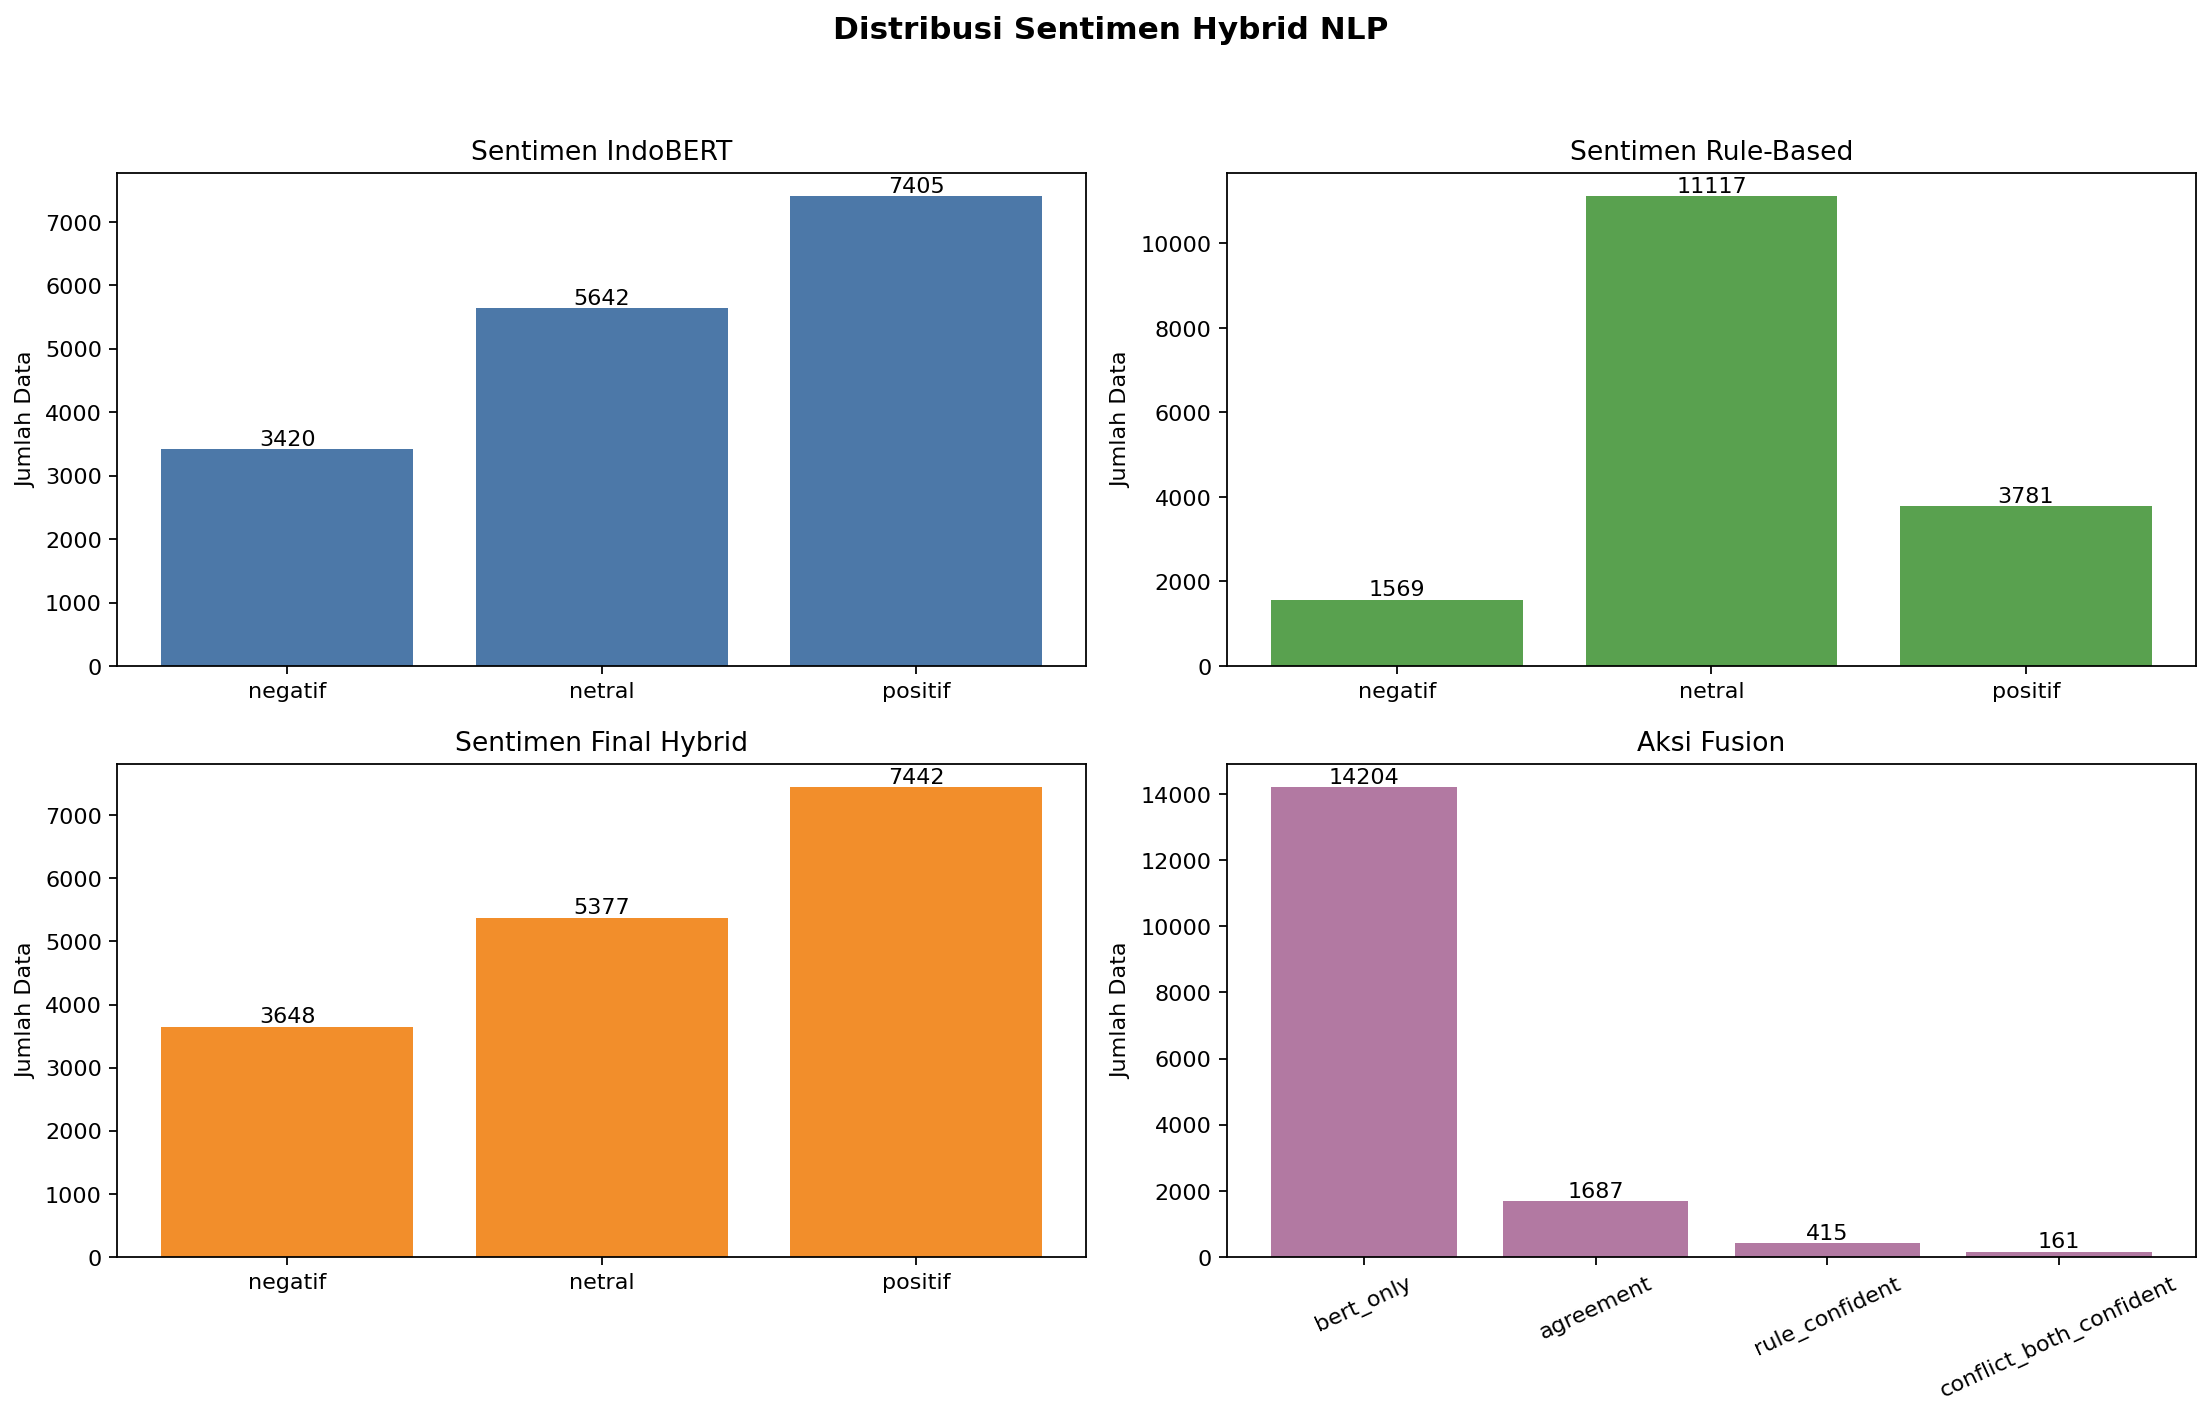

kalbar_location_distribution.png


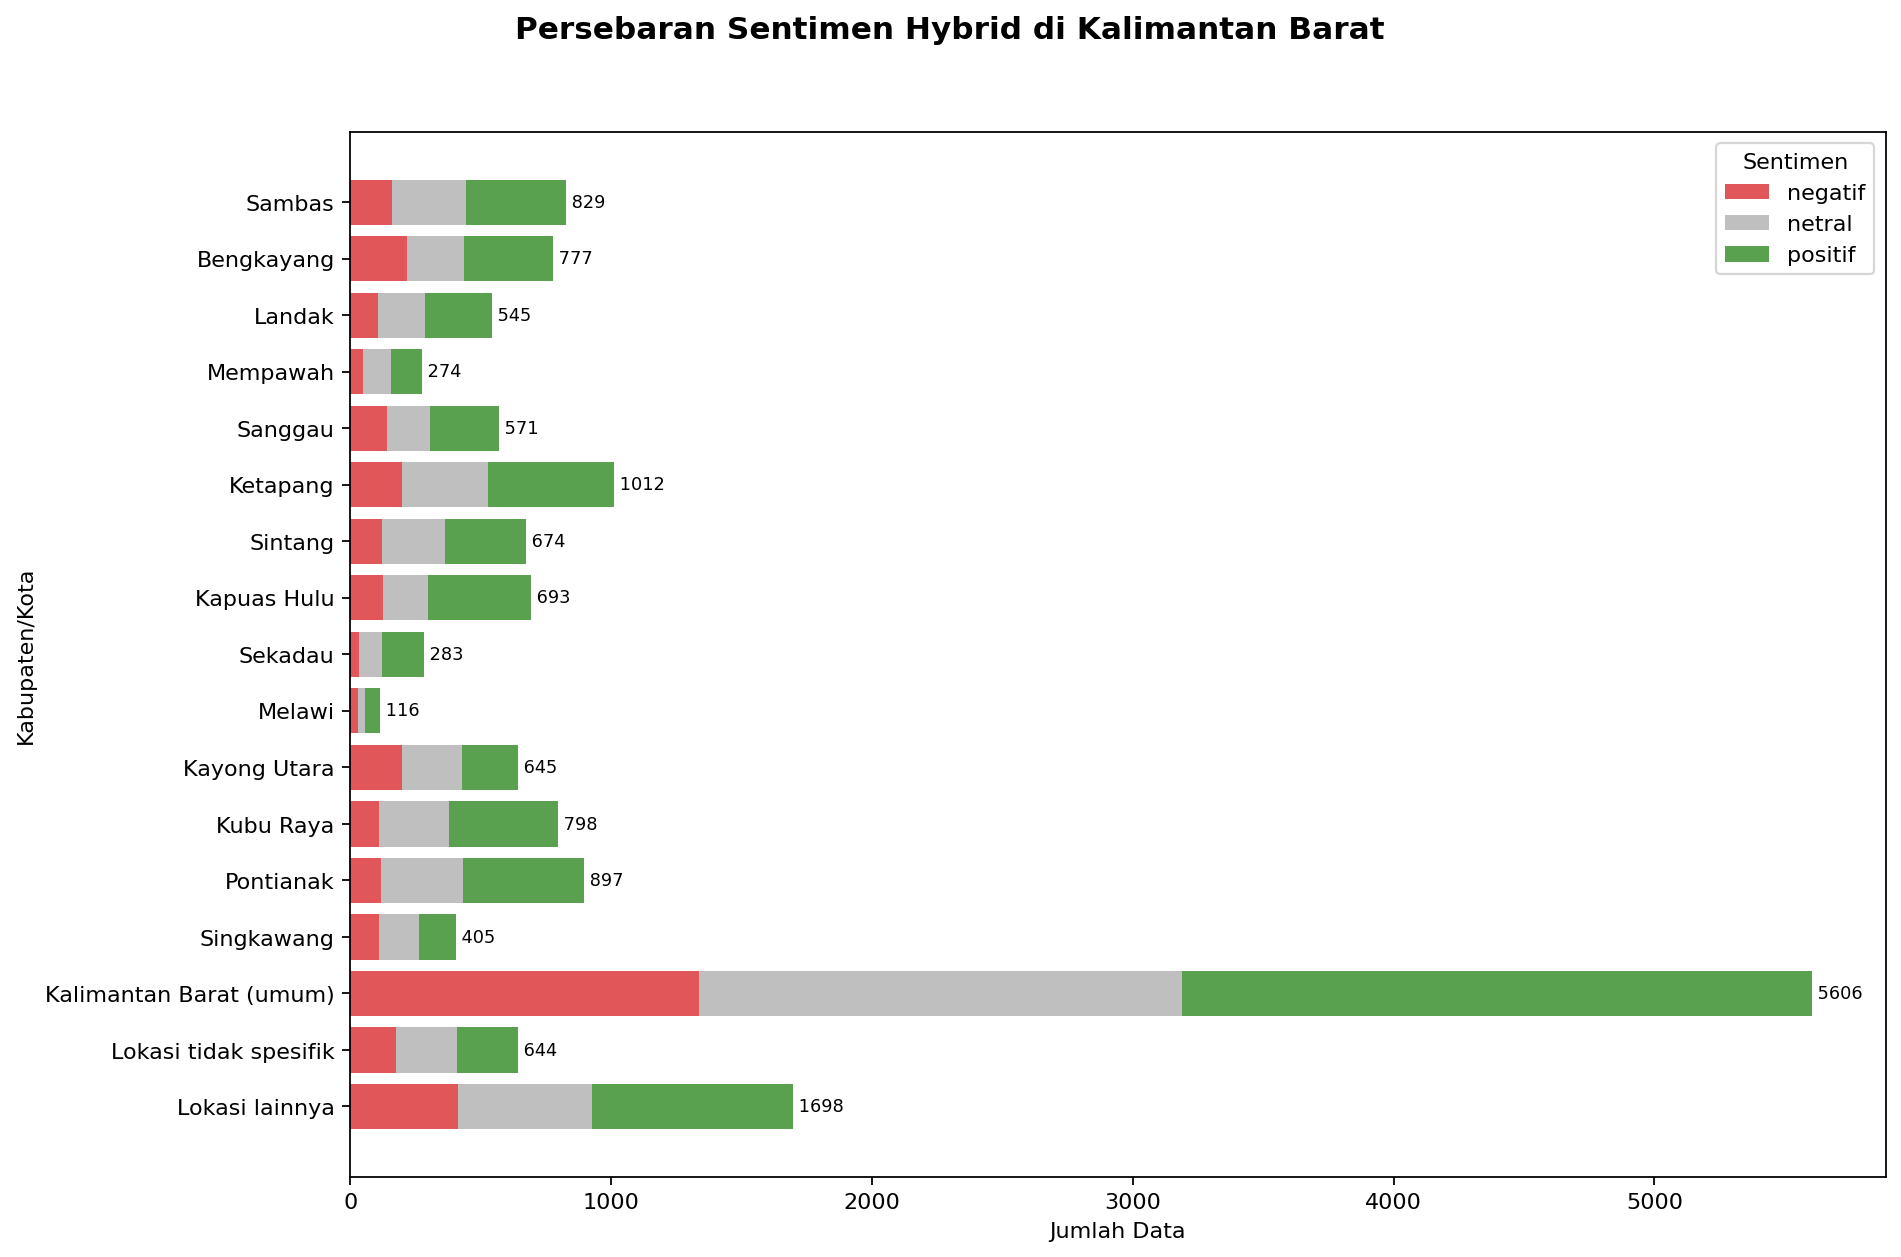

topic_keywords_by_sentiment.png


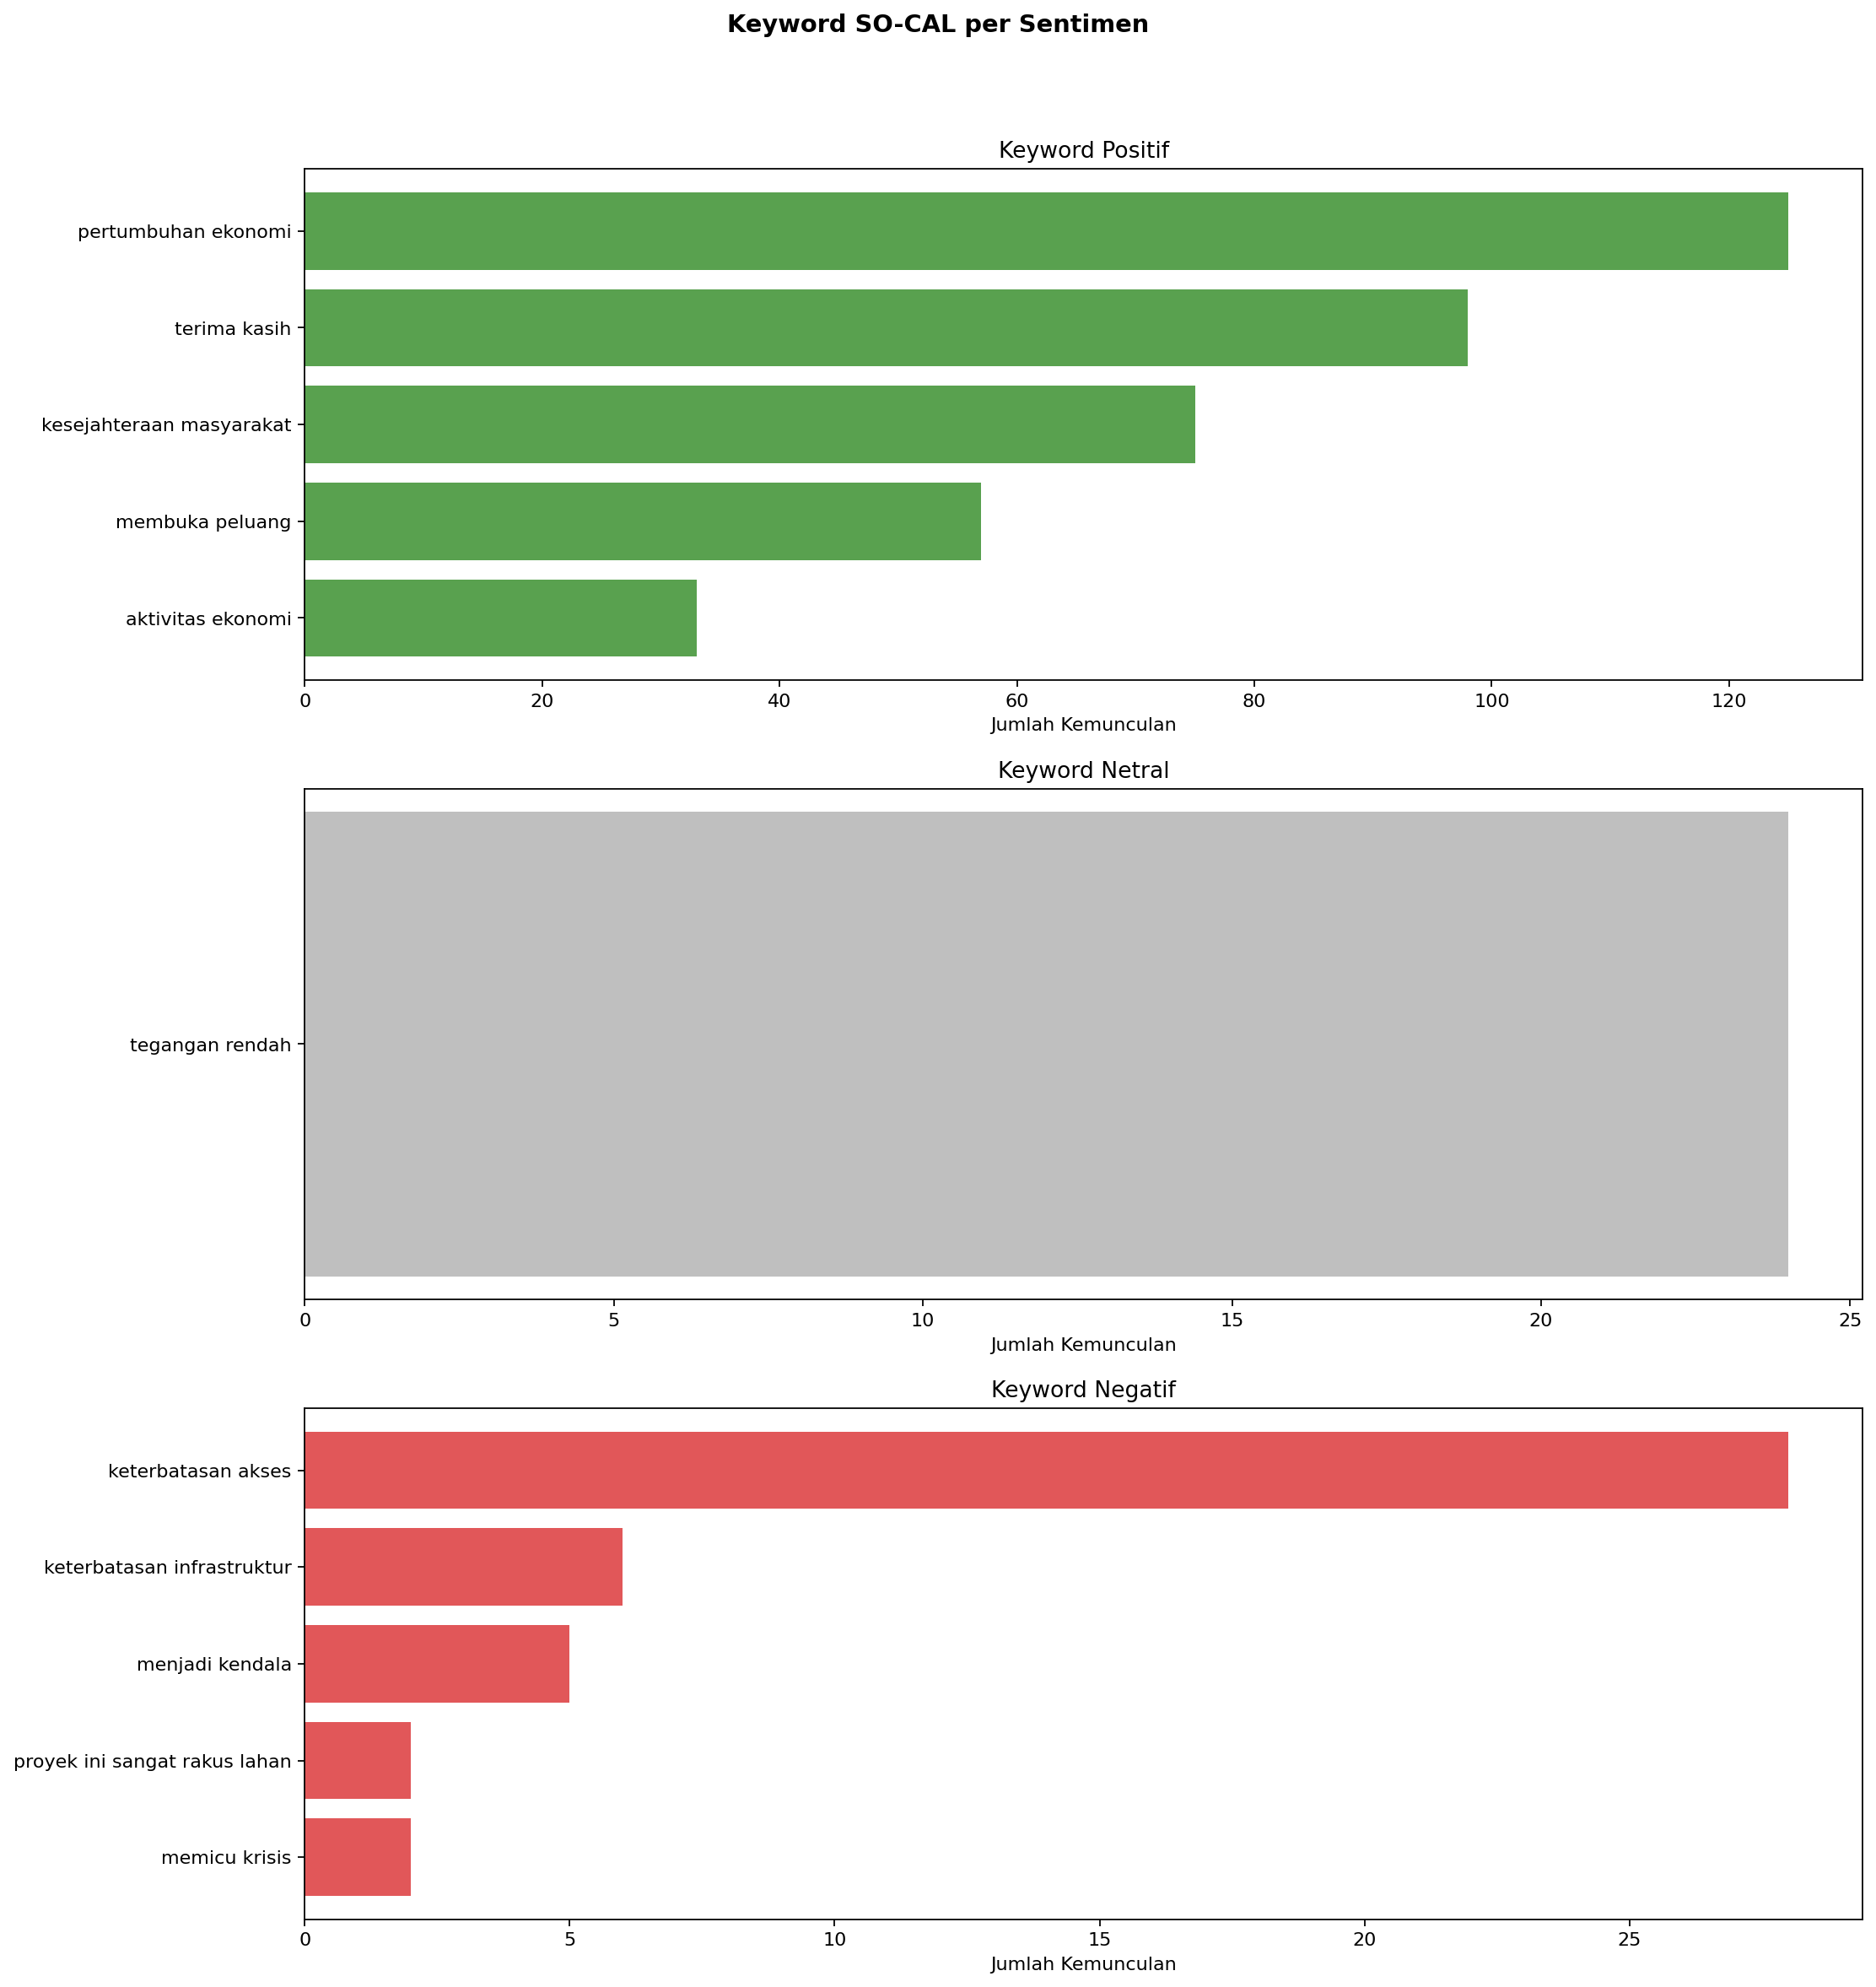

indobert_to_hybrid_transition.png


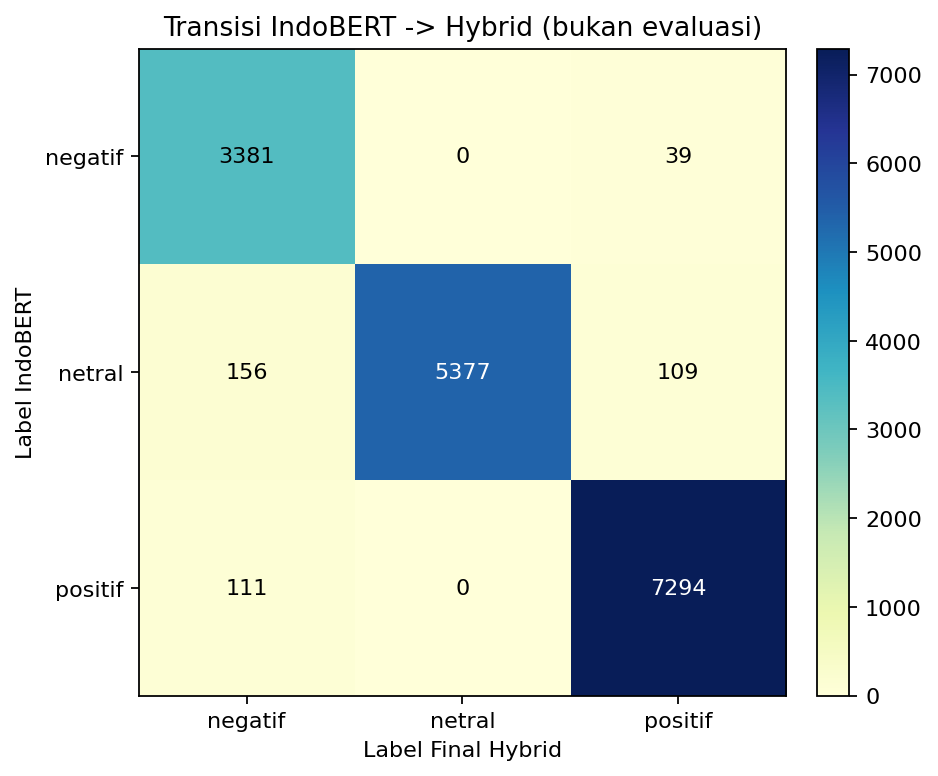

held_out_method_comparison.png


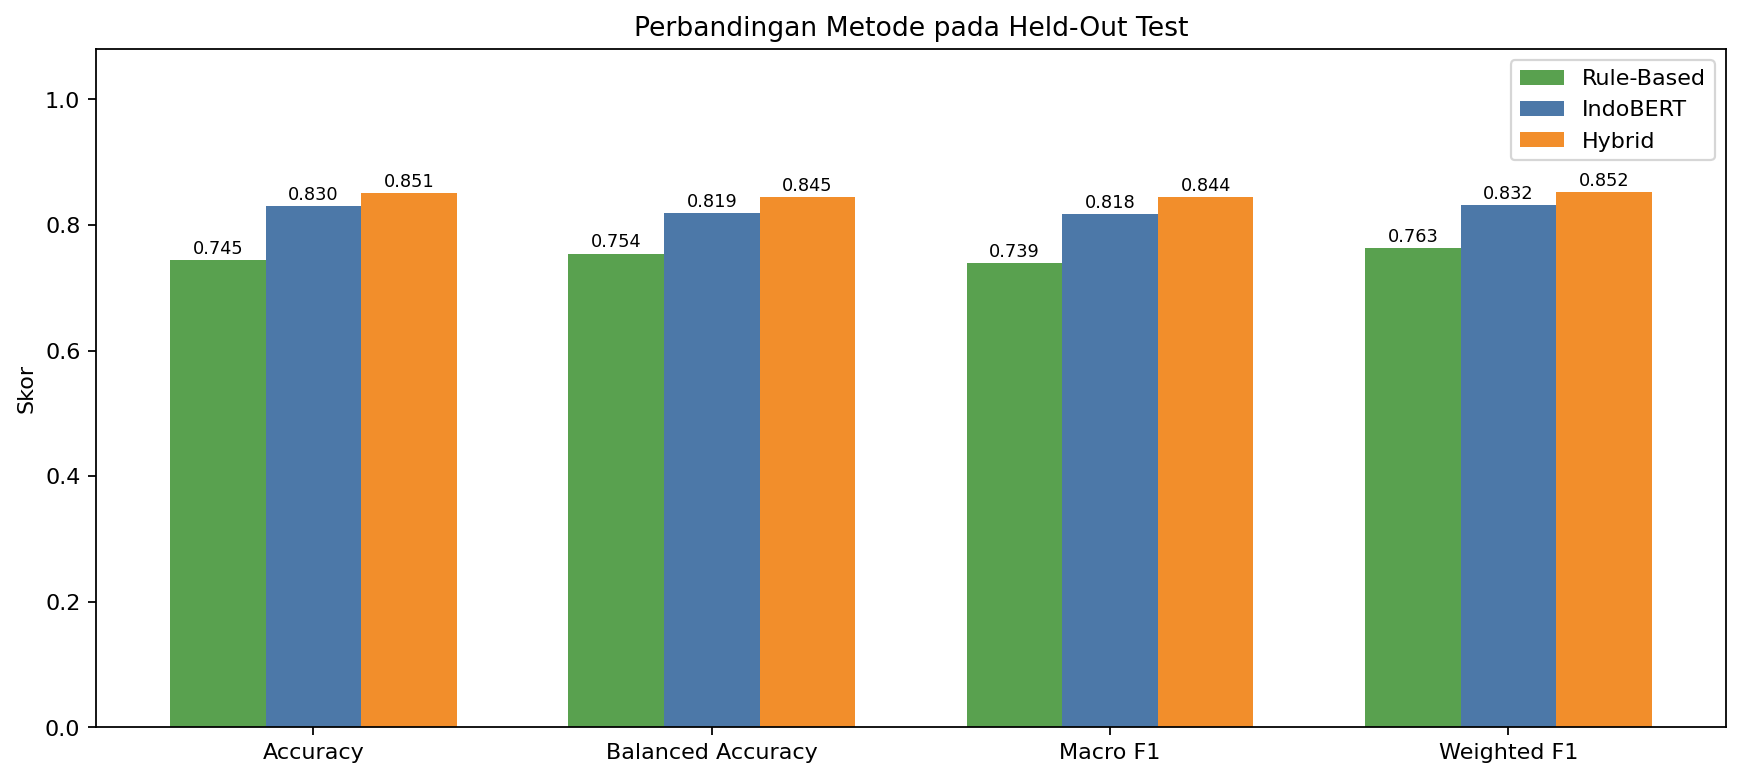

held_out_per_label_confusion.png


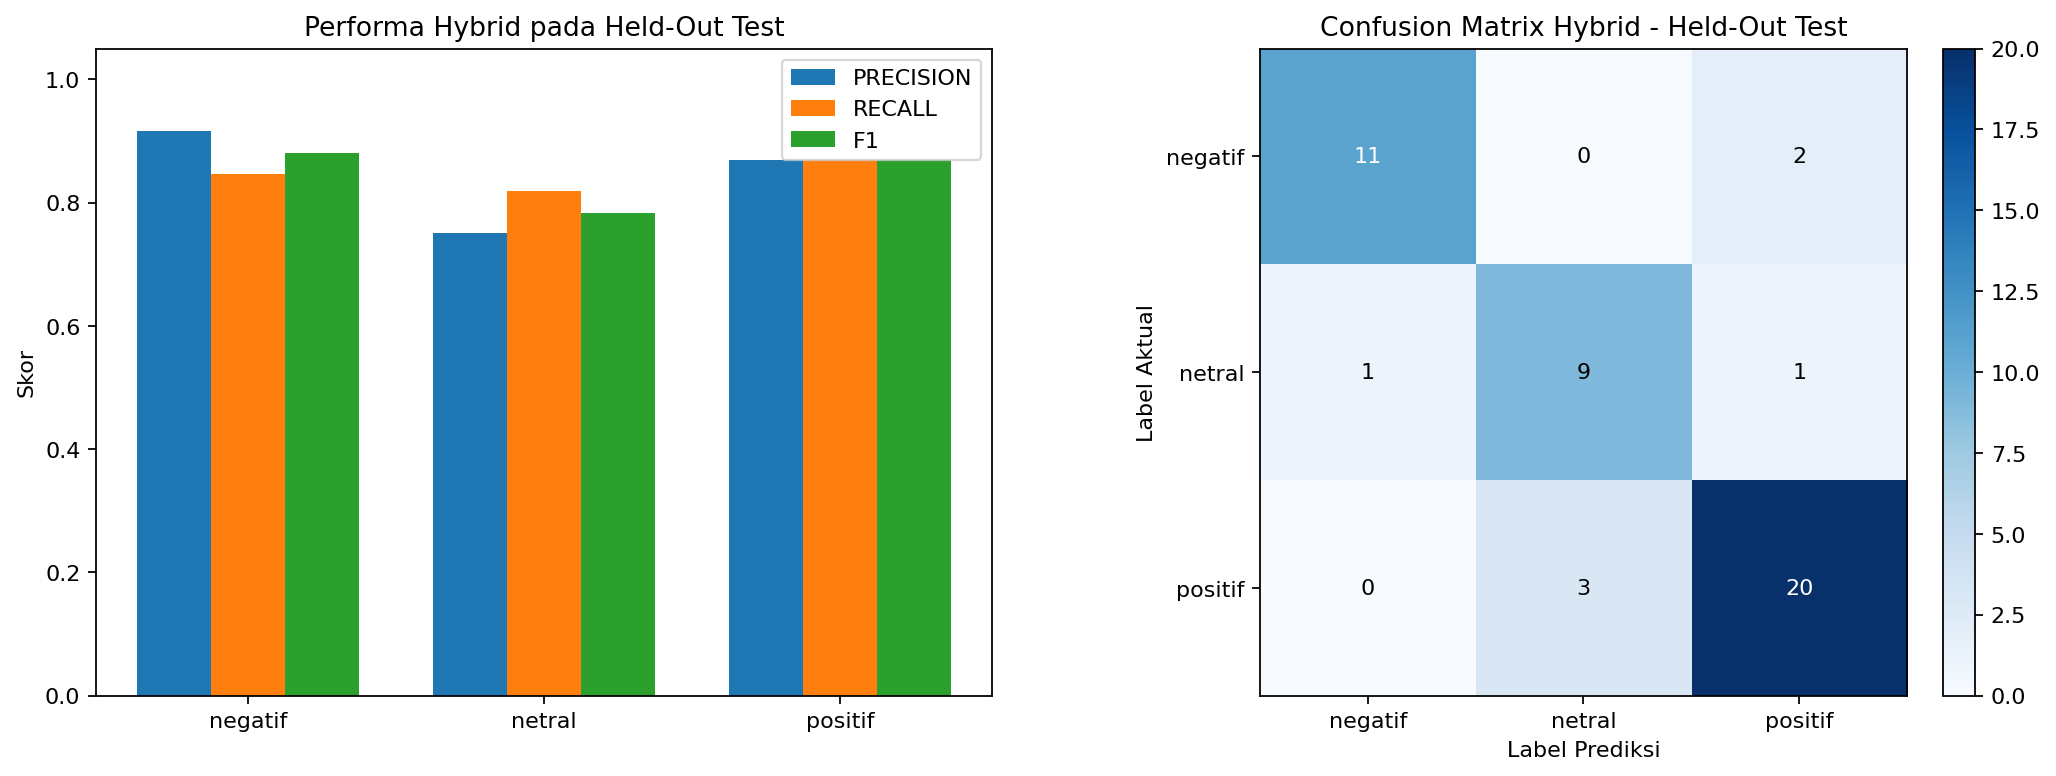

dataset_split_and_runtime_distribution.png


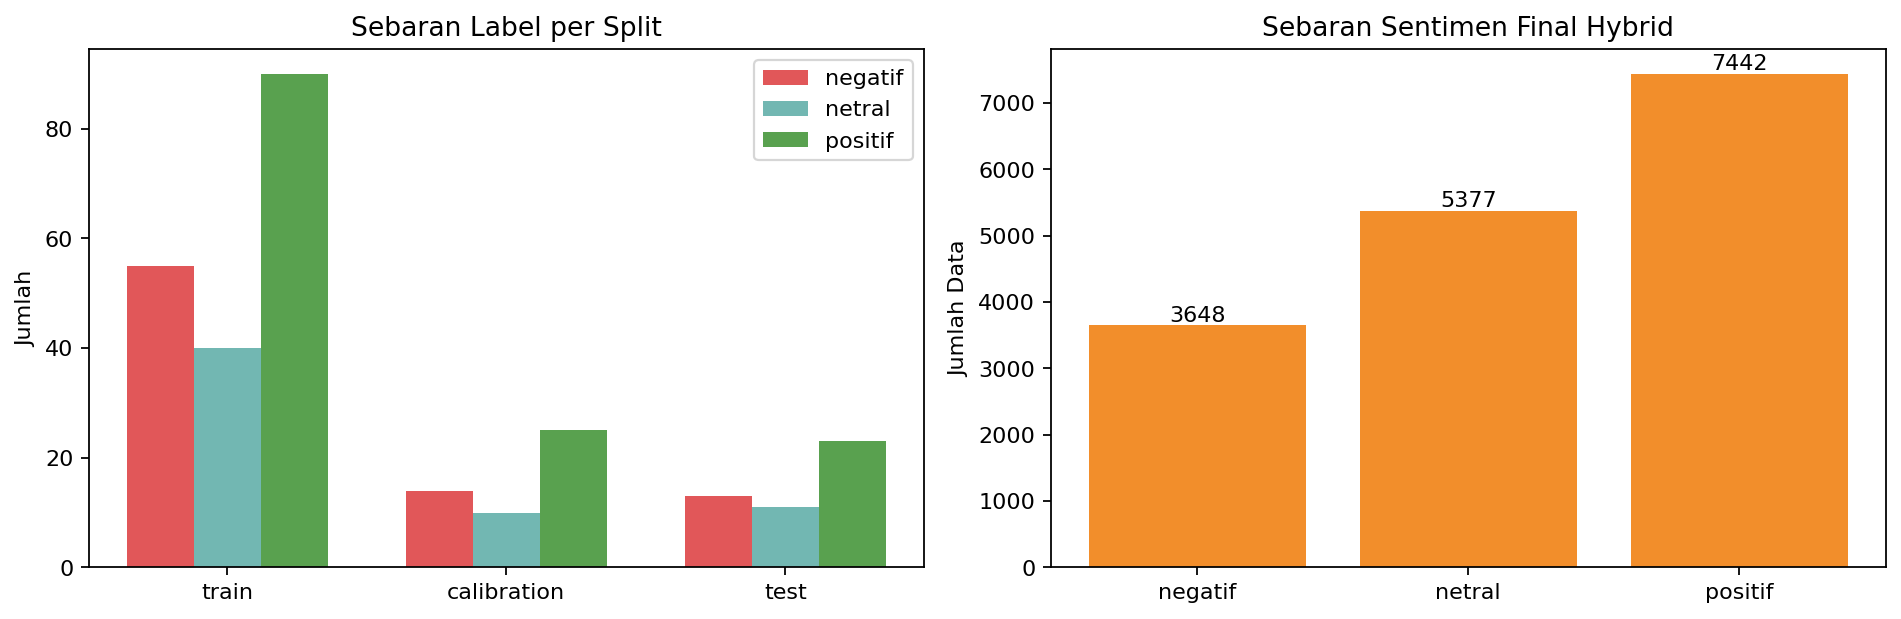

domain_and_source_type_distribution.png


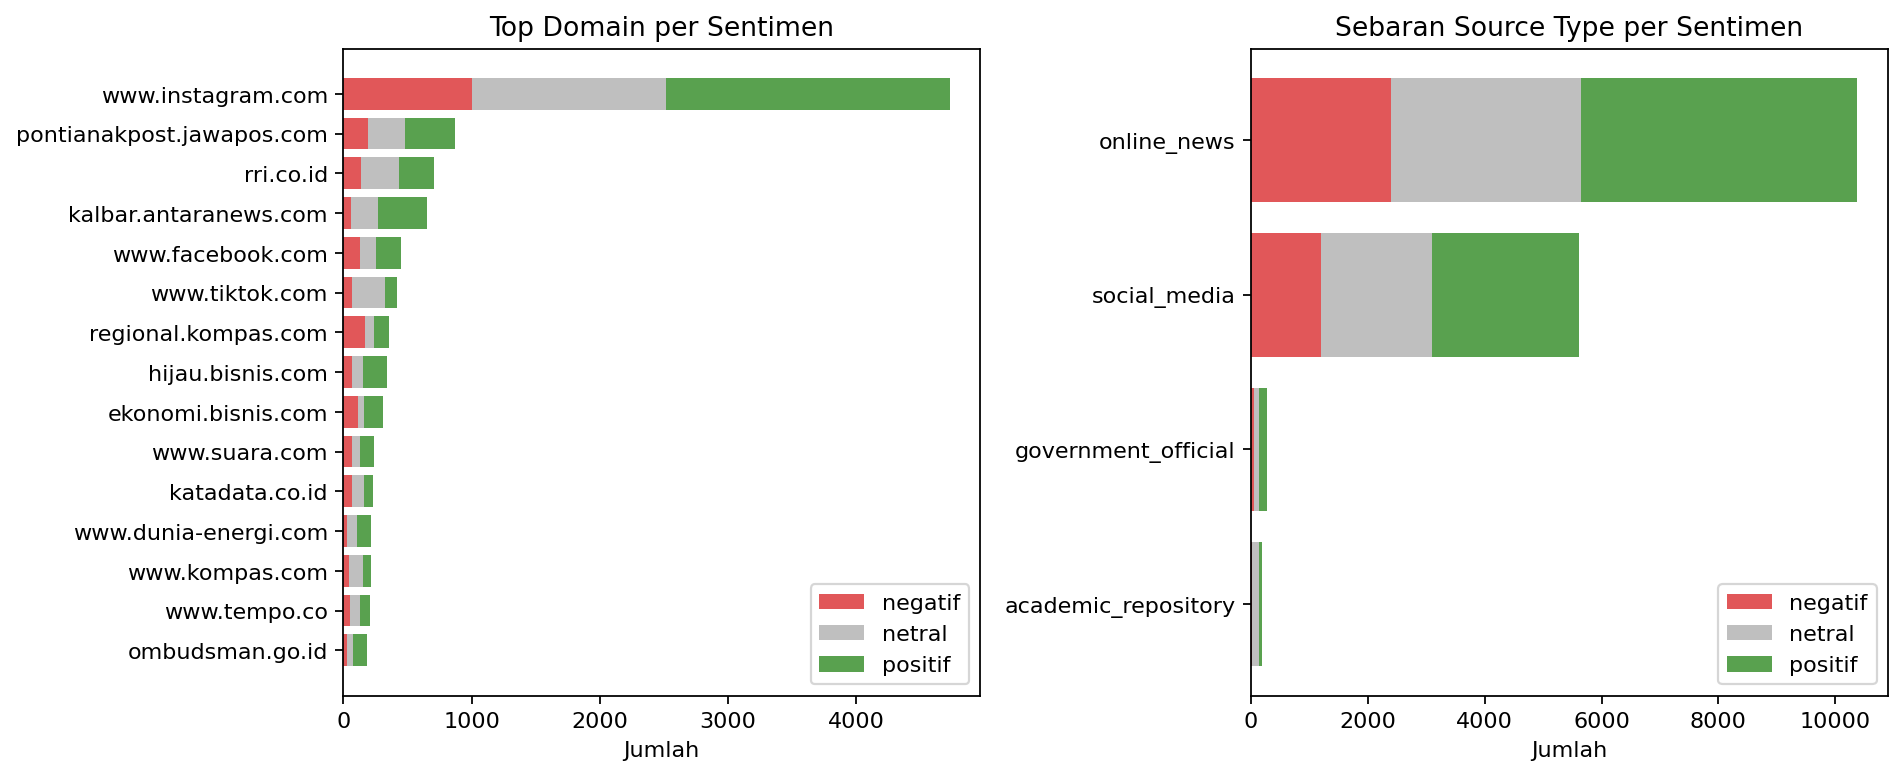

aspect_distribution.png


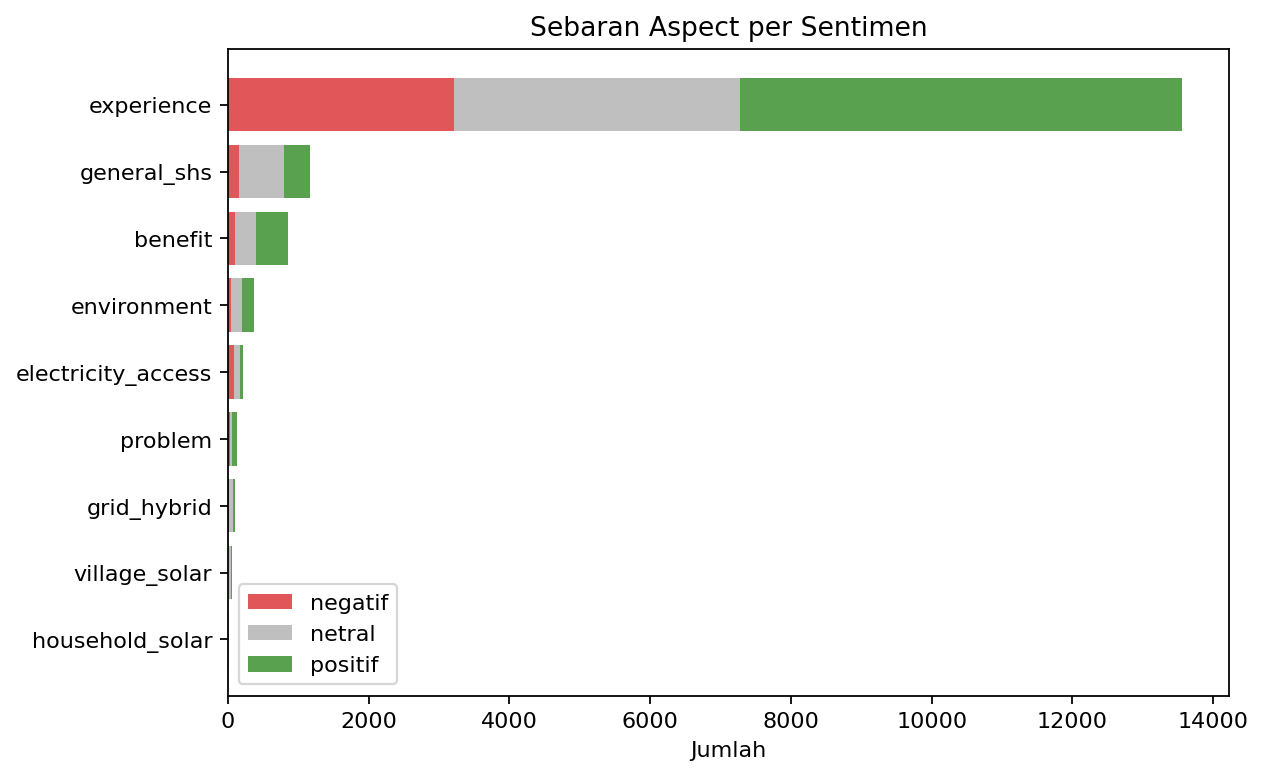

In [11]:
artifact_paths = {
    "training_dataset": config.TRAINING_DATASET_PATH,
    "training_dataset_with_split": config.TRAINING_DATASET_WITH_SPLIT_PATH,
    "model_dir": MODEL_DIR,
    "calibration_artifact": CALIBRATION_ARTIFACT_PATH,
    "fusion_policy": FUSION_POLICY_PATH,
    "fusion_metrics": FUSION_METRICS_PATH,
    "held_out_test_predictions": HYBRID_TEST_PREDICTIONS_PATH,
    "hybrid_predictions": HYBRID_PREDICTIONS_PATH,
    "hybrid_summary": HYBRID_RUNTIME_SUMMARY_PATH,
    "hybrid_manifest": HYBRID_RUNTIME_MANIFEST_PATH,
    "classification_report": HYBRID_CLASSIFICATION_REPORT_PATH,
    "evaluation_metrics": HYBRID_EVALUATION_METRICS_PATH,
    "sentiment_figure": HYBRID_SENTIMENT_FIGURE_PATH,
    "kalbar_figure": HYBRID_KALBAR_FIGURE_PATH,
    "topic_keyword_figure": HYBRID_FIGURES_DIR / "topic_keywords_by_sentiment.png",
    "transition_figure": HYBRID_FIGURES_DIR / "indobert_to_hybrid_transition.png",
    "held_out_comparison_figure": HYBRID_FIGURES_DIR / "held_out_method_comparison.png",
    "held_out_per_label_figure": HYBRID_FIGURES_DIR / "held_out_per_label_confusion.png",
    "split_runtime_figure": HYBRID_FIGURES_DIR / "dataset_split_and_runtime_distribution.png",
    "domain_source_figure": HYBRID_FIGURES_DIR / "domain_and_source_type_distribution.png",
    "aspect_figure": HYBRID_FIGURES_DIR / "aspect_distribution.png",
    "report_manifest": HYBRID_REPORT_MANIFEST_PATH,
    "topic_assignments": TOPIC_ASSIGNMENTS_PATH,
    "topic_summary": TOPIC_SUMMARY_PATH,
    "topic_keyword_blacklist": TOPIC_KEYWORD_BLACKLIST_PATH,
}

artifact_df = pl.DataFrame([
    {"artifact": name, "path": str(path), "exists": Path(path).exists()}
    for name, path in artifact_paths.items()
])
display(artifact_df)

from IPython.display import Image
figure_artifacts = [
    path for name, path in artifact_paths.items()
    if name.endswith("_figure") and Path(path).exists()
]
print(f"Visualisasi tersimpan: {len(figure_artifacts)}/9")
for figure_path in figure_artifacts:
    print(figure_path.name)
    display(Image(filename=str(figure_path)))


## Diagnostik B. Manifest dan Metrics


In [12]:
def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    return artifact_service.load_json(path)


training_manifest = load_json_if_exists(config.ARTIFACTS / "training_dataset_manifest.json")
split_manifest = load_json_if_exists(config.FIXED_SPLIT_MANIFEST_PATH)
calibration_artifact = load_json_if_exists(CALIBRATION_ARTIFACT_PATH)
indobert_metrics = load_json_if_exists(INDOBERT_METRICS_PATH)
fusion_metrics = load_json_if_exists(FUSION_METRICS_PATH)
hybrid_summary = load_json_if_exists(HYBRID_RUNTIME_SUMMARY_PATH)
hybrid_evaluation = load_json_if_exists(HYBRID_EVALUATION_METRICS_PATH)
topic_summary_artifact = load_json_if_exists(TOPIC_SUMMARY_PATH)


## Diagnostik C. Sebaran Dataset dan Runtime Hybrid


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if config.TRAINING_DATASET_WITH_SPLIT_PATH.exists():
    split_df = pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH)
    grouped = split_df.group_by(["split", "sentiment_label"]).len().to_dicts()
    splits = ["train", "calibration", "test"]
    x = range(len(splits))
    width = 0.24
    colors = {"negatif": "#e45756", "netral": "#72b7b2", "positif": "#54a24b"}
    for offset, label in enumerate(LABEL_ORDER):
        values = [
            next(
                (
                    int(row["len"])
                    for row in grouped
                    if row["split"] == split and row["sentiment_label"] == label
                ),
                0,
            )
            for split in splits
        ]
        positions = [item + (offset - 1) * width for item in x]
        axes[0].bar(positions, values, width=width, label=label, color=colors[label])
    axes[0].set_title("Sebaran Label per Split")
    axes[0].set_xticks(list(x), splits)
    axes[0].set_ylabel("Jumlah")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Split dataset belum tersedia", ha="center", va="center")
    axes[0].set_axis_off()

if HYBRID_PREDICTIONS_PATH.exists():
    predictions_df = pl.read_parquet(HYBRID_PREDICTIONS_PATH)
    hybrid_counts = counts_from_series(predictions_df["final_sentiment"].to_list())
    plot_count_bar(
        axes[1],
        hybrid_counts,
        "Sebaran Sentimen Final Hybrid",
        xlabel="Sentiment",
        order=LABEL_ORDER,
    )
else:
    axes[1].text(0.5, 0.5, "Runtime predictions belum tersedia", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout(pad=1.2)
plt.close(fig)  # figure kanonis ditampilkan dari artefak report


## Diagnostik D. Lokasi dan Metadata Runtime


In [14]:
import csv
import re
from urllib.parse import urlparse


KALBAR_PROVINCE_LABEL = "Kalimantan Barat (provinsi/fallback)"
KALBAR_SPECIFIC_LABEL = "Kabupaten/Kota spesifik"
EMPTY_LOCATION_LABEL = "(lokasi kosong)"
OTHER_LOCATION_LABEL = "(di luar daftar Kalbar)"
KALBAR_PROVINCE_ALIASES = {"kalimantan barat", "kalbar"}


def load_metadata_distribution_df():
    if HYBRID_PREDICTIONS_PATH.exists():
        return pl.read_parquet(HYBRID_PREDICTIONS_PATH), f"runtime hybrid: {HYBRID_PREDICTIONS_PATH}"
    if config.TRAINING_DATASET_WITH_SPLIT_PATH.exists():
        return pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH), f"training split: {config.TRAINING_DATASET_WITH_SPLIT_PATH}"
    if config.RAW_CANDIDATE_SCHEMA_PATH.exists():
        return pl.read_csv(config.RAW_CANDIDATE_SCHEMA_PATH, infer_schema_length=10_000, ignore_errors=True), f"raw candidate: {config.RAW_CANDIDATE_SCHEMA_PATH}"
    return None, ""


def read_csv_rows(path: Path) -> list[dict[str, str]]:
    if not path.exists():
        return []
    with path.open(encoding=config.ENCODING, newline="") as handle:
        return list(csv.DictReader(handle))


def canonical_kalbar_location_name(name: str) -> str:
    value = re.sub(r"\s+", " ", str(name or "").strip())
    value = re.sub(r"^(kabupaten|kab\.?|kota)\s+", "", value, flags=re.IGNORECASE)
    return value.title()


def load_kalbar_regency_names() -> list[str]:
    province_code = ""
    for row in read_csv_rows(config.RESOURCES / "wilayah" / "provinsi.csv"):
        if str(row.get("name") or "").casefold() == "kalimantan barat":
            province_code = str(row.get("code") or "").strip()
            break

    names = []
    seen = set()
    for row in read_csv_rows(config.RESOURCES / "wilayah" / "kabupaten.csv"):
        if str(row.get("parent_code") or "").strip() != province_code:
            continue
        name = canonical_kalbar_location_name(row.get("name") or "")
        key = name.casefold()
        if name and key not in seen:
            names.append(name)
            seen.add(key)
    return names


def raw_values_for_distribution(df, column):
    if column not in df.columns:
        return [""] * df.height
    return [str(value or "").strip() for value in df[column].to_list()]


def values_for_distribution(df, column):
    values = raw_values_for_distribution(df, column)
    return [value or "(kosong)" for value in values]


def sentiment_values_for_distribution(df):
    if "final_sentiment" in df.columns:
        values = values_for_distribution(df, "final_sentiment")
        if any(value in LABEL_ORDER for value in values):
            return values, "final_sentiment"
    if "indobert_sentiment" in df.columns:
        values = values_for_distribution(df, "indobert_sentiment")
        if any(value in LABEL_ORDER for value in values):
            return values, "indobert_sentiment"
    if "bert_label" in df.columns:
        values = values_for_distribution(df, "bert_label")
        if any(value in LABEL_ORDER for value in values):
            return values, "bert_label"
    if "sentiment_label" in df.columns:
        values = [
            value if value in LABEL_ORDER else "(tanpa sentiment)"
            for value in values_for_distribution(df, "sentiment_label")
        ]
        return values, "sentiment_label"
    return ["(tanpa sentiment)"] * df.height, "(tanpa sentiment)"


def domain_values(df):
    if "raw_domain" in df.columns:
        values = values_for_distribution(df, "raw_domain")
        if any(value != "(kosong)" for value in values):
            return values
    if "domain" in df.columns:
        values = values_for_distribution(df, "domain")
        if any(value != "(kosong)" for value in values):
            return values
    if "source_url" not in df.columns:
        return []
    domains = []
    for url in df["source_url"].to_list():
        parsed = urlparse(str(url or ""))
        domains.append(parsed.netloc.lower() or "(kosong)")
    return domains


def sentiment_order(values):
    extras = sorted({value for value in values if value not in LABEL_ORDER})
    return [label for label in LABEL_ORDER if label in values] + extras


def grouped_counts_by_sentiment(category_values, sentiment_values):
    totals = {}
    grouped = {}
    for category, sentiment in zip(category_values, sentiment_values):
        category = str(category or "").strip() or "(kosong)"
        sentiment = str(sentiment or "").strip() or "(tanpa sentiment)"
        totals[category] = totals.get(category, 0) + 1
        grouped.setdefault(category, {})[sentiment] = grouped.setdefault(category, {}).get(sentiment, 0) + 1
    return totals, grouped


def plot_count_by_sentiment_barh(
    ax,
    category_values,
    sentiment_values,
    title,
    *,
    top_n=15,
    category_order=None,
):
    if not sentiment_values or (category_order is None and not category_values):
        ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
        ax.set_axis_off()
        return

    totals, grouped = grouped_counts_by_sentiment(category_values, sentiment_values)
    if category_order is None:
        if not totals:
            ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
            ax.set_axis_off()
            return
        labels = [label for label, _total in sorted(totals.items(), key=lambda item: (-item[1], item[0]))[:top_n]]
    else:
        labels = list(category_order)

    y_positions = list(range(len(labels)))
    left = [0] * len(labels)
    colors = {
        "negatif": "#d62728",
        "netral": "#7f7f7f",
        "positif": "#2ca02c",
        "(tanpa sentiment)": "#bdbdbd",
    }

    for sentiment in sentiment_order(sentiment_values):
        numbers = [grouped.get(label, {}).get(sentiment, 0) for label in labels]
        if not any(numbers):
            continue
        ax.barh(
            y_positions,
            numbers,
            left=left,
            label=sentiment,
            color=colors.get(sentiment, "#4c78a8"),
        )
        left = [current + value for current, value in zip(left, numbers)]

    ax.set_yticks(y_positions, labels)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Jumlah")
    ax.tick_params(axis="y", labelsize=8)
    max_total = max(left or [0])
    ax.set_xlim(0, max(1, max_total * 1.15))
    for index, total in enumerate(left):
        ax.text(total, index, f" {total}", va="center", fontsize=8)
    if any(left):
        ax.legend(loc="best", fontsize=8)


def kalbar_specific_location_values(location_values, regency_names):
    lookup = {name.casefold(): name for name in regency_names}
    values = []
    for value in location_values:
        canonical = canonical_kalbar_location_name(value)
        values.append(lookup.get(canonical.casefold(), OTHER_LOCATION_LABEL))
    return values


def kalbar_scope_values(location_values, regency_names):
    lookup = {name.casefold(): name for name in regency_names}
    values = []
    for value in location_values:
        canonical = canonical_kalbar_location_name(value)
        key = canonical.casefold()
        if not canonical:
            values.append(EMPTY_LOCATION_LABEL)
        elif key in lookup:
            values.append(KALBAR_SPECIFIC_LABEL)
        elif key in KALBAR_PROVINCE_ALIASES:
            values.append(KALBAR_PROVINCE_LABEL)
        else:
            values.append(OTHER_LOCATION_LABEL)
    return values


metadata_df, metadata_source = load_metadata_distribution_df()
if metadata_df is None:
    print("Dataset metadata belum tersedia. Jalankan build raw candidate atau runtime hybrid lebih dulu.")
else:
    sentiment_values, sentiment_column = sentiment_values_for_distribution(metadata_df)
    location_values = raw_values_for_distribution(metadata_df, "location")
    kalbar_regency_names = load_kalbar_regency_names()
    specific_location_values = kalbar_specific_location_values(location_values, kalbar_regency_names)
    scope_location_values = kalbar_scope_values(location_values, kalbar_regency_names)

    print(f"Sumber metadata: {metadata_source}")
    print(f"Jumlah row: {metadata_df.height:,}")
    print(f"Kolom sentiment: {sentiment_column}")
    print(f"Jumlah kabupaten/kota Kalbar ditampilkan: {len(kalbar_regency_names)}")

    specific_totals, specific_grouped = grouped_counts_by_sentiment(specific_location_values, sentiment_values)
    display(
        pl.DataFrame(
            [
                {
                    "kabupaten_kota": location,
                    "total": int(specific_totals.get(location, 0)),
                    "negatif": int(specific_grouped.get(location, {}).get("negatif", 0)),
                    "netral": int(specific_grouped.get(location, {}).get("netral", 0)),
                    "positif": int(specific_grouped.get(location, {}).get("positif", 0)),
                }
                for location in kalbar_regency_names
            ]
        )
    )

    fig_height = max(6, len(kalbar_regency_names) * 0.42)
    fig, axes = plt.subplots(1, 2, figsize=(14, fig_height))
    plot_count_by_sentiment_barh(
        axes[0],
        specific_location_values,
        sentiment_values,
        "Kabupaten/Kota Kalbar per Sentiment",
        category_order=kalbar_regency_names,
    )
    plot_count_by_sentiment_barh(
        axes[1],
        scope_location_values,
        sentiment_values,
        "Provinsi Fallback vs Lokasi Spesifik",
        category_order=[KALBAR_SPECIFIC_LABEL, KALBAR_PROVINCE_LABEL, EMPTY_LOCATION_LABEL, OTHER_LOCATION_LABEL],
    )
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_count_by_sentiment_barh(
        axes[0],
        domain_values(metadata_df),
        sentiment_values,
        "Top Domain per Sentiment",
        top_n=15,
    )
    plot_count_by_sentiment_barh(
        axes[1],
        values_for_distribution(metadata_df, "source_type"),
        sentiment_values,
        "Sebaran Source Type per Sentiment",
        top_n=15,
    )
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    plot_count_by_sentiment_barh(
        ax,
        values_for_distribution(metadata_df, "aspect"),
        sentiment_values,
        "Sebaran Aspect per Sentiment",
        top_n=15,
    )
    fig.tight_layout(pad=1.2)
    plt.close(fig)  # figure kanonis ditampilkan dari artefak report


Sumber metadata: runtime hybrid: E:\School\tugas-akhir\project\outputs\artifacts\experiments\indobert_nlp_manual\runtime_hybrid\scenario_without_llm_predictions.parquet
Jumlah row: 16,467
Kolom sentiment: final_sentiment
Jumlah kabupaten/kota Kalbar ditampilkan: 14


kabupaten_kota,total,negatif,netral,positif
str,i64,i64,i64,i64
"""Sambas""",829,159,285,385
"""Bengkayang""",777,219,216,342
"""Landak""",545,107,178,260
"""Mempawah""",274,49,108,117
"""Sanggau""",571,140,167,264
…,…,…,…,…
"""Melawi""",116,29,27,60
"""Kayong Utara""",645,198,229,218
"""Kubu Raya""",798,112,265,421


## Diagnostik E. Kalibrasi Rule-Based

Threshold aktif `0.60` dievaluasi terhadap target minimum precision-on-fired `0.97`. Sel ini melaporkan precision dan coverage aktual; target 100% tidak lagi menjadi syarat kontrak.


In [15]:
import glob
import json
from pathlib import Path

import numpy as np

import config
from services.lexicon_sentiment_service import LexiconSentimentService
from services.preprocessing_service import PreprocessingService

lexicon = LexiconSentimentService()
preprocess = PreprocessingService()
print("Ambang detected (RULE_WEAK_THRESHOLD):", lexicon.weak_threshold)
print("Target minimum precision:", config.RULE_MIN_PRECISION)
print("Resource versions:", lexicon.resource_versions)

# Muat golden dataset (referensi berlabel manual)
golden_rows = []
for path in sorted(glob.glob(str(config.GOLDEN_DATASET_DIR / "*.json"))):
    for row in json.load(open(path, encoding="utf-8")):
        golden_rows.append((row["text_id"], row["text_selected"], row["sentiment"]))
print("Golden rows:", len(golden_rows))


Ambang detected (RULE_WEAK_THRESHOLD): 0.6
Target minimum precision: 0.95
Resource versions: {'metadata': '1.2.1', 'word_rules': '1.2.0', 'phrase_rules': '1.1.0', 'modifiers': '1.2.0'}
Golden rows: 281


In [16]:
# Jalankan rule-based pada seluruh golden (preprocessing -> lexicon)
analyzed = []
for text_id, text, gold in golden_rows:
    processed = preprocess.process(text)["processed_text"]
    res = lexicon.analyze_text(processed)
    analyzed.append({
        "text_id": text_id,
        "gold": gold,
        "label": res[config.COL_RULE_LABEL],
        "confidence": float(res[config.COL_RULE_CONFIDENCE]),
        "score": float(res[config.COL_RULE_SCORE]),
        "status": res[config.COL_RULE_STATUS],
    })

from collections import Counter
print("Distribusi gold:", dict(Counter(a["gold"] for a in analyzed)))
print("Distribusi status rule:", dict(Counter(a["status"] for a in analyzed)))


Distribusi gold: {'positif': 138, 'negatif': 82, 'netral': 61}
Distribusi status rule: {'weak': 56, 'detected': 92, 'unknown': 133}


In [17]:
# Sweep diagnostik confidence untuk melihat trade-off precision dan coverage.
# 'fired' = rule bukan unknown, confidence >= threshold, dan label non-netral.
def evaluate_at(threshold):
    fired = [
        row
        for row in analyzed
        if row["status"] != config.RULE_STATUS_UNKNOWN
        and row["confidence"] >= threshold
        and row["label"] != "netral"
    ]
    if not fired:
        return None
    correct = sum(1 for row in fired if row["label"] == row["gold"])
    return {
        "threshold": threshold,
        "fired": len(fired),
        "correct": correct,
        "precision": correct / len(fired),
        "coverage": len(fired) / len(analyzed),
    }


print(f"{'T':>5} {'fired':>6} {'correct':>8} {'precision':>10} {'coverage':>9}  status")
for threshold in [round(value, 3) for value in np.arange(0.05, 1.001, 0.05)]:
    row = evaluate_at(threshold)
    if row is None:
        continue
    flags = []
    if row["precision"] >= config.RULE_MIN_PRECISION:
        flags.append("memenuhi target")
    if abs(threshold - config.RULE_WEAK_THRESHOLD) < 1e-9:
        flags.append("AMBANG AKTIF")
    print(
        f"{threshold:>5.2f} {row['fired']:>6} {row['correct']:>8} "
        f"{row['precision']:>10.3f} {row['coverage']:>9.3f}  {', '.join(flags)}"
    )

active_diagnostic = evaluate_at(config.RULE_WEAK_THRESHOLD)
print("\nFakta pada ambang aktif:", active_diagnostic)


    T  fired  correct  precision  coverage  status
 0.05    147      144      0.980     0.523  memenuhi target
 0.10    146      143      0.979     0.520  memenuhi target
 0.15    145      142      0.979     0.516  memenuhi target
 0.20    145      142      0.979     0.516  memenuhi target
 0.25    138      136      0.986     0.491  memenuhi target
 0.30    135      133      0.985     0.480  memenuhi target
 0.35    129      127      0.984     0.459  memenuhi target
 0.40    120      118      0.983     0.427  memenuhi target
 0.45    113      111      0.982     0.402  memenuhi target
 0.50    101       99      0.980     0.359  memenuhi target
 0.55     92       90      0.978     0.327  memenuhi target
 0.60     92       90      0.978     0.327  memenuhi target, AMBANG AKTIF
 0.65     86       84      0.977     0.306  memenuhi target
 0.70     84       82      0.976     0.299  memenuhi target
 0.75     74       73      0.986     0.263  memenuhi target
 0.80     69       68      0.986   

In [18]:
# Verifikasi threshold aktif terhadap kontrak minimum precision.
active = evaluate_at(config.RULE_WEAK_THRESHOLD)
assert active is not None, "Tidak ada baris fired pada ambang aktif"
print("Ambang aktif    :", config.RULE_WEAK_THRESHOLD)
print("Target precision:", config.RULE_MIN_PRECISION)
print("Fired           :", active["fired"], "/", len(analyzed))
print("Correct         :", active["correct"], "/", active["fired"])
print("Precision       : %.4f" % active["precision"])
print("Coverage        : %.4f" % active["coverage"])
assert active["precision"] >= config.RULE_MIN_PRECISION, (
    "KALIBRASI GAGAL: precision-on-fired berada di bawah "
    f"target minimum {config.RULE_MIN_PRECISION:.2f}."
)
print("\nOK: threshold aktif memenuhi target minimum precision-on-fired.")

# Fakta kesalahan pada threshold aktif, tanpa menyembunyikannya.
active_errors = [
    row
    for row in analyzed
    if row["status"] != config.RULE_STATUS_UNKNOWN
    and row["confidence"] >= config.RULE_WEAK_THRESHOLD
    and row["label"] != "netral"
    and row["label"] != row["gold"]
]
print("\nKesalahan rule pada ambang aktif:", len(active_errors))
for row in active_errors:
    print(
        f"  [{row['text_id']}] gold={row['gold']} pred={row['label']} "
        f"conf={row['confidence']:.2f}"
    )


Ambang aktif    : 0.6
Target precision: 0.95
Fired           : 92 / 281
Correct         : 90 / 92
Precision       : 0.9783
Coverage        : 0.3274

OK: threshold aktif memenuhi target minimum precision-on-fired.

Kesalahan rule pada ambang aktif: 2
  [RAW-0737#04] gold=positif pred=negatif conf=0.70
  [RAW-0461#01] gold=netral pred=positif conf=0.83
